Fetching MNIST data...
Dataset sampled to: X=(70000, 784), y=(70000,)


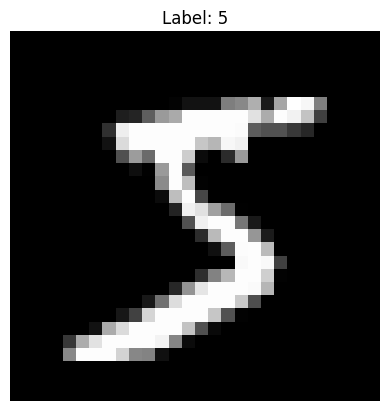

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

print("Fetching MNIST data...")
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

X = X[:70000] / 255.0
y = y[:70000].astype(np.int64)

print(f"Dataset sampled to: X={X.shape}, y={y.shape}")




plt.imshow(X[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y[0]}")
plt.axis("off")
plt.show()

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import StackingClassifier


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


base_models = [
    ('knn', KNeighborsClassifier(n_neighbors=11)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('log_reg', LogisticRegression(max_iter=3000)),
    ('dt', DecisionTreeClassifier(max_depth=15, random_state=42)),
    ('nb', GaussianNB()),
    ('l_svc', LinearSVC(dual=False, random_state=42, max_iter=3000))
]


In [3]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



model_names = []
model_accs = []

print("--- Base Model Accuracies ---")
for name, model in base_models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: {acc:.4f}")
    model_names.append(name.upper())
    model_accs.append(acc)



stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=3000),
    cv=3,
    n_jobs=1
)


print("Training Stacking Classifier .... ")

stacking_model.fit(X_train, y_train)
print("Training complete!")

--- Base Model Accuracies ---
knn: 0.9644
rf: 0.9668
log_reg: 0.9210
dt: 0.8734
nb: 0.5510
l_svc: 0.9119
Training Stacking Classifier .... 
Training complete!


Stacking Classifier testing Accuracy: 97.72%
Stacking Classifier train Accuracy: 99.90%

Classification Report training:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4845
           1       1.00      1.00      1.00      5513
           2       1.00      1.00      1.00      4857
           3       1.00      1.00      1.00      4965
           4       1.00      1.00      1.00      4888
           5       1.00      1.00      1.00      4398
           6       1.00      1.00      1.00      4788
           7       1.00      1.00      1.00      5045
           8       1.00      1.00      1.00      4833
           9       1.00      1.00      1.00      4868

    accuracy                           1.00     49000
   macro avg       1.00      1.00      1.00     49000
weighted avg       1.00      1.00      1.00     49000


Classification Report testing:
              precision    recall  f1-score   support

           0       0.99      0.99

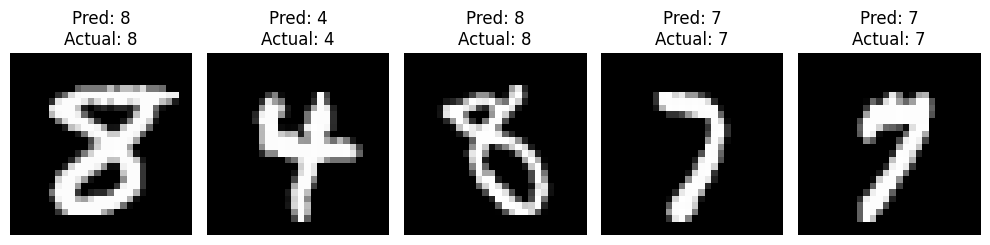

In [4]:

y_pred_test =stacking_model.predict(X_test)
stack_accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Stacking Classifier testing Accuracy: {stack_accuracy_test * 100:.2f}%")

model_names.append('STACKING')
model_accs.append(stack_accuracy_test)

y_pred_train = stacking_model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred_train)

print(f"Stacking Classifier train Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report training:")
print(classification_report(y_train, y_pred_train))
print("\nClassification Report testing:")
print(classification_report(y_test, y_pred_test))




plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {y_pred_test[i]}\nActual: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

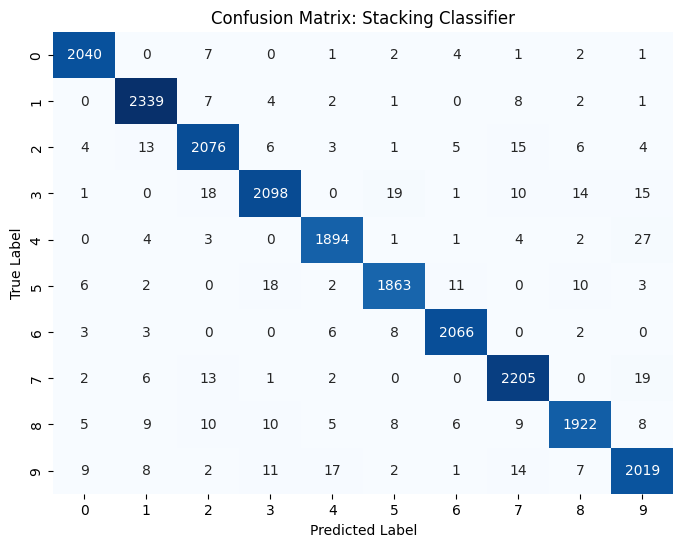

In [5]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Stacking Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [6]:
import os
from PIL import Image, ImageOps
import numpy as np
from scipy.ndimage import center_of_mass, shift
import matplotlib.pyplot as plt

def preprocess_mnist_image(img_path):
    img = Image.open(img_path).convert("L")
    img = ImageOps.autocontrast(img)
    img = ImageOps.invert(img) if np.mean(img) > 127 else img
    img = img.point(lambda p: 255 if p > 120 else 0)

    bbox = img.getbbox()
    if not bbox:
        return np.zeros((28, 28), dtype="float32")

    img = img.crop(bbox)
    img.thumbnail((20, 20), Image.Resampling.LANCZOS)

    new_img = Image.new("L", (28, 28), 0)
    new_img.paste(img, ((28 - img.width) // 2, (28 - img.height) // 2))
    img_array = np.array(new_img)

    cy, cx = center_of_mass(img_array)
    sy, sx = np.round(14.0 - cy), np.round(14.0 - cx)
    img_array = shift(img_array, shift=(sy, sx), cval=0)

    return img_array.astype("float32") / 255.0


img_path = "/content/mnist_output_5.png"

if os.path.exists(img_path):
    try:
        print(f"Processing '{img_path}'...")
        img_array = preprocess_mnist_image(img_path)

        img_flat = img_array.reshape(1, -1)
        probs = stacking_model.predict_proba(img_flat)[0]
        prediction = np.argmax(probs)
        confidence = np.max(probs)

        plt.figure(figsize=(4, 4))
        plt.imshow(img_array, cmap="gray")
        plt.title(f"Pred: {prediction} ({confidence:.1%})\n{os.path.basename(img_path)}", fontsize=10)
        plt.axis("off")
        plt.show()

    except Exception as e:
        print(f"Error processing {img_path}: {e}")
else:
    print(f"Error: Could not find the file '{img_path}'. Please check the path.")

Error: Could not find the file '/content/mnist_output_5.png'. Please check the path.


In [7]:
import joblib

In [8]:
joblib.dump(stacking_model, 'mnist.joblib')

['mnist.joblib']

In [9]:
stacking_model = joblib.load('mnist.joblib')

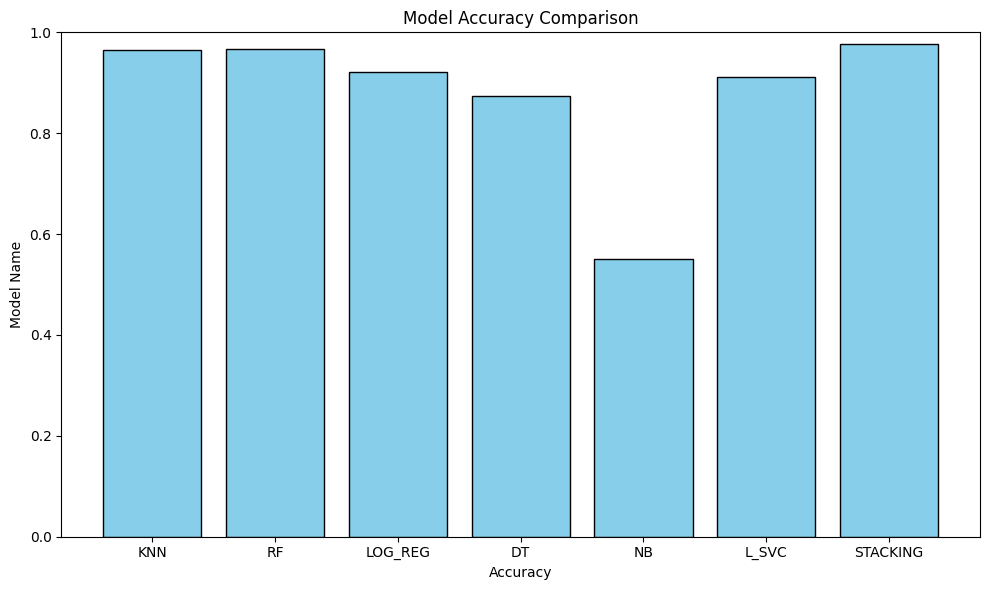

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accs, color='skyblue', edgecolor='black')

plt.xlabel('Accuracy')
plt.ylabel('Model Name')
plt.title('Model Accuracy Comparison')
plt.ylim(0,1)

plt.tight_layout()
plt.show()